In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from src.data import DATASETS, RANDOM_STATE, load_splits
from src.metrics import log_loss
from src.plots import cv_curve

sns.set_theme(style="whitegrid", context="paper")
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
FIG_DIR = ROOT / "report" / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
data = {}
for name in DATASETS:
    X_train, X_cal, X_test, y_train, y_cal, y_test = load_splits(name)
    data[name] = {"train": (X_train, y_train), "cal": (X_cal, y_cal), "test": (X_test, y_test)}

In [3]:
K_FOLDS = 5


def stratified_kfold(y, k=K_FOLDS, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    fold = np.empty(len(y), dtype=int)
    for c in np.unique(y):
        idx = rng.permutation(np.flatnonzero(y == c))
        fold[idx] = np.arange(len(idx)) % k
    for f in range(k):
        yield np.flatnonzero(fold != f), np.flatnonzero(fold == f)


def cv_log_loss(make_model, X, y):
    train, val = [], []
    for tr, va in stratified_kfold(y):
        model = make_model().fit(X[tr], y[tr])
        train.append(log_loss(y[tr], model.predict_proba(X[tr])[:, 1]))  
        val.append(log_loss(y[va], model.predict_proba(X[va])[:, 1]))
    return np.mean(train), np.mean(val), np.std(val)

In [4]:
GRIDS = {
    "LR": ("C", [0.001, 0.01, 0.1, 1, 10, 100],
           lambda v: LogisticRegression(C=v, max_iter=1000)),
    "RF": ("min_samples_leaf", [1, 2, 5, 10, 20],
           lambda v: RandomForestClassifier(n_estimators=200, max_features="sqrt",
                                            min_samples_leaf=v, n_jobs=-1,
                                            random_state=RANDOM_STATE)),
}

rows = []
for name in DATASETS:
    X,y = data[name]["train"]
    for model_name, (param, values, make) in GRIDS.items():
        for value in values:
            train, val, val_std = cv_log_loss(lambda: make(value), X, y)
            rows.append({"dataset": name, "model": model_name, "param": param, "value": value,
                         "train_log_loss": train, "val_log_loss": val, "val_std": val_std})

cv_results = pd.DataFrame(rows)
cv_results.to_csv(RESULTS_DIR / "cv_results.csv", index=False)

In [5]:
best_params = {}
for (name, model_name), g in cv_results.groupby(["dataset", "model"], sort=False):
    param, values, _ = GRIDS[model_name]
    i = int(np.argmin(g["val_log_loss"].to_numpy()))   
    best_params[name, model_name] = {param: values[i]}
    edge = "  <- edge of the grid" if i in (0, len(values) - 1) else ""
    print(f"{name:10s} {model_name}: {param} = {values[i]:<6} val log-loss = {g['val_log_loss'].iloc[i]:.4f}{edge}")

higgs      LR: C = 0.1    val log-loss = 0.6410
higgs      RF: min_samples_leaf = 5      val log-loss = 0.5622
covertype  LR: C = 100    val log-loss = 0.5107  <- edge of the grid
covertype  RF: min_samples_leaf = 1      val log-loss = 0.3342  <- edge of the grid
adult      LR: C = 0.1    val log-loss = 0.3302
adult      RF: min_samples_leaf = 2      val log-loss = 0.3161


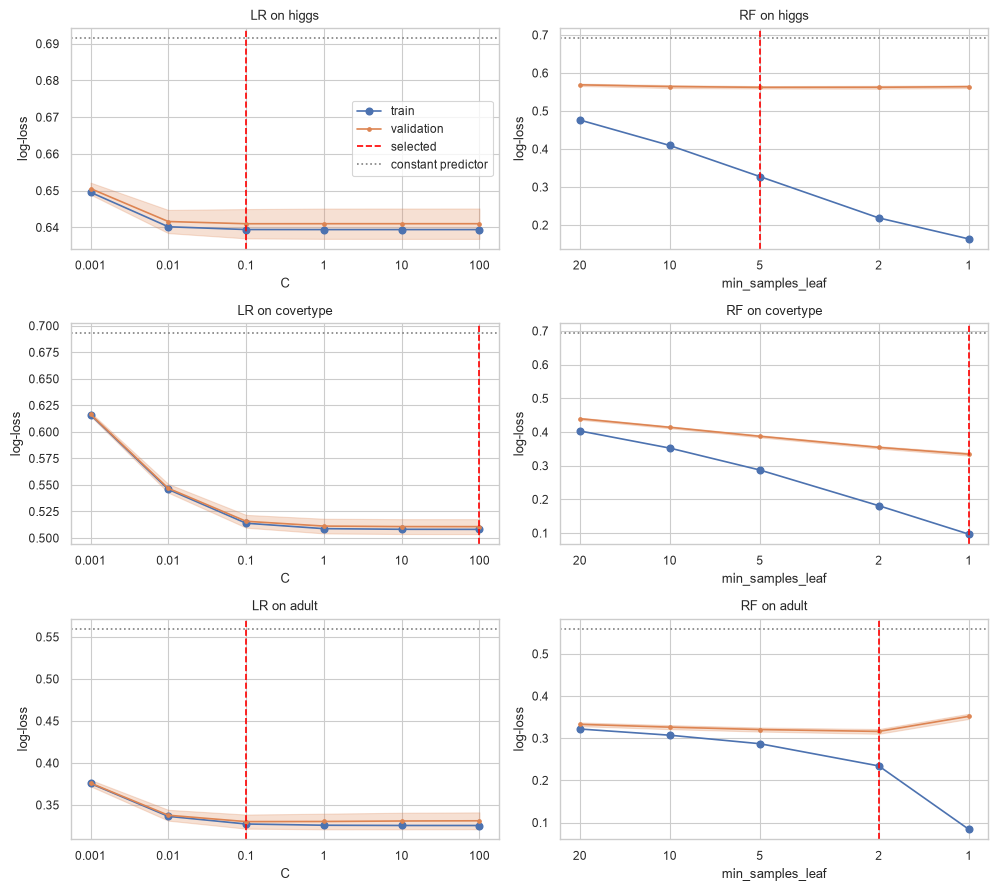

In [6]:
fig, axes = plt.subplots(len(DATASETS), len(GRIDS), figsize=(10, 9))
for i, name in enumerate(DATASETS):
    y = data[name]["train"][1]
    baseline = log_loss(y, np.full(len(y), y.mean()))
    for j, (model_name, (param, values, _)) in enumerate(GRIDS.items()):
        g = cv_results[(cv_results["dataset"] == name) & (cv_results["model"] == model_name)]
        cv_curve(axes[i, j], values, g["train_log_loss"], g["val_log_loss"], g["val_std"],
                 best=best_params[name, model_name][param], baseline=baseline,
                 invert=(param == "min_samples_leaf"))
        axes[i, j].set(title=f"{model_name} on {name}", xlabel=param, ylabel="log-loss")
axes[0, 0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cv_curves.pdf")